# Looking at data from Bell Field

This is a generic code for looking at the continous HOBO data against the manual field measurements for one Bell Field Piezometer. The notebook is written for piezometer one (P1), so change the variables to match your actual column names.

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

The code chunk below installs the package that runs a hampel filter--this is what cleans the spikes out of the data caused by removing the hobo sensors from the wells. After running it once, the package is installed in your environment, and you should comment out the cell to keep your cache clear.

In [2]:
# pip install hampel

In [3]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [4]:
import os # Allows python to communicate directly with the computer's operating system

# Reading in the Hobo data

In [5]:
# Import P1_current.csv, the file with all updated P1 data as "P1hobodf"
P1hobodf = pd.read_csv('P1_current.csv')
P1hobodf = P1hobodf.dropna()

# Change the 'Date-Time' column to the pandas datetime format
P1hobodf['Date-Time'] = pd.to_datetime(P1hobodf['Date-Time']) 
# Index P1hobodf by the datetime with a Pandas Datetimeindex. This allows us to reassign the correct dates after passing the data through the hampel filter.
P1hobodf.index = pd.DatetimeIndex(P1hobodf['Date-Time']) 

In [6]:
# Run P1hobodf to get a summary of the first and last five rows in P1hobodf. 
# Alternatively, use P1hobodf.head() to see the first five or P1hobodf.tail() to see the last five.
P1hobodf

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids
Date-Time,,,,,,
2024-11-06 14:16:29,2024-11-06 14:16:29,13.780000,3.500000,4.500000,0.010000,2.260000
2024-11-06 14:31:29,2024-11-06 14:31:29,15.170000,531.200000,669.400000,0.320000,345.270000
2024-11-06 14:46:29,2024-11-06 14:46:29,15.230000,532.800000,670.400000,0.320000,346.320000
2024-11-06 15:01:29,2024-11-06 15:01:29,15.190000,533.400000,671.900000,0.320000,346.720000
2024-11-06 15:16:29,2024-11-06 15:16:29,15.130000,533.400000,672.800000,0.320000,346.710000
...,...,...,...,...,...,...
2026-07-21 08:15:00,2026-07-21 08:15:00,15.283695,656.992676,825.411682,0.398047,427.045227
2026-07-21 08:30:00,2026-07-21 08:30:00,15.283695,656.970642,825.383972,0.398033,427.030914
2026-07-21 08:45:00,2026-07-21 08:45:00,15.283695,657.136780,825.592712,0.398137,427.138885


# Filtering the data

A hampel filter uses a running average to compute outliers in time-dependent data. Instead of dropping outliers, it replaces them with the local median. Visit https://www.mathworks.com/help/signal/ref/hampel.html for more information.

In [7]:
# Run the filter on the Temperature column. This produces a type of data called a "hampel.result.Result". 
# The window size is the number of neighbors (k) on either side of the sample. Default k=3.
# The n_sigma is the number of standard deviations by which a sample must differ from the local median to be replaced with that median. Default nsigma=3.
P1filtered = hampel(P1hobodf['Temperature'], window_size=6, n_sigma=1.5)

In [8]:
# The hampel result has an internal index that must be stripped away to add the data back into our data frame. 
# Rewrite P1filtered as a NumPy array, and then as a DataFrame with P1hobodf's original datetime index. Problem solved by Google Gemini.
P1filtered = pd.DataFrame(P1filtered.filtered_data.to_numpy(), index=P1hobodf.index)

In [9]:
# Add a column called "FilteredTemp" to the original P1hobodf dataframe with all the filtered data. This works because P1filtered is a dataframe with the same index.
P1hobodf['FilteredTemp'] = P1filtered

Repeat the filter for the Specific Conductivity data.

In [10]:
# Filter the SPC measurements.
P1filteredSPC = hampel(P1hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
P1filteredSPC = pd.DataFrame(P1filteredSPC.filtered_data.to_numpy(), index=P1hobodf.index)
P1hobodf['FilteredSPC'] = P1filteredSPC

# Add in the other datasets

In [11]:
# Add the manual YSI data.
P1mandf = pd.read_csv('Manual_Data_P1.csv', index_col=False) 
P1mandf['Date'] = pd.to_datetime(P1mandf['Date']) 

In [13]:
# Add the NOAA air temp data.
weatherdf = pd.read_csv('NOAAHastingsDamTemp.csv')
weatherdf['Date'] = pd.to_datetime(weatherdf['Date'])

The creek data also has to be filtered for spikes. In the case of P1, there is a temperature dot next to the well (called C1) and an MX801 conductivity logger a few yards downstream (called downst).

In [14]:
# Add in C1.
C1hobodf = pd.read_csv('P1_creek_current.csv') 
C1hobodf['Date-Time'] = pd.to_datetime(C1hobodf['Date-Time']) 
C1hobodf.index = pd.DatetimeIndex(C1hobodf['Date-Time'])

In [15]:
# Filter C1 the same way as P1.
C1filtered = hampel(C1hobodf['Temperature'], window_size=6, n_sigma=1.5)
C1filtered = pd.DataFrame(C1filtered.filtered_data.to_numpy(), index=C1hobodf.index)
C1hobodf['FilteredTemp'] = C1filtered

In [52]:
# Add in downstream conductivity monitor.
downst = pd.read_csv('Dwnstrm_current.csv') 
downst['Date-Time'] = pd.to_datetime(downst['Date-Time']) 
downst.index = pd.DatetimeIndex(downst['Date-Time'])

In [54]:
# Filter downst.
downfilt = hampel(downst['Temperature'], window_size=6, n_sigma=1.5)
downfilt = pd.DataFrame(downfilt.filtered_data.to_numpy(), index=downst.index)
downst['FilteredTemp'] = downfilt

In [56]:
downfilt = hampel(downst['Specific Conductivity'], window_size=6, n_sigma=1.5)
downfilt = pd.DataFrame(downfilt.filtered_data.to_numpy(), index=downst.index)
downst['FilteredSPC'] = downfilt

# Plot the data

There are a lot of things to visualize! I've tried to lay out everything that I find most helpful, but you will have to play around a bit to see for yourself.

Here is a key:  
  
fig, ax=plt.subplots(figsize = [adjustable dimension])  
ax.plot(x, y, 'shape of marker', color='[whatever color you want]', alpha = [less than 1 is transparent], label='[the name of the thing you are plotting]')  
ax.scatter(x, y, s= [smaller number makes a smaller dot], color='[]', alpha = [], label='[]')

Plotting temperature:

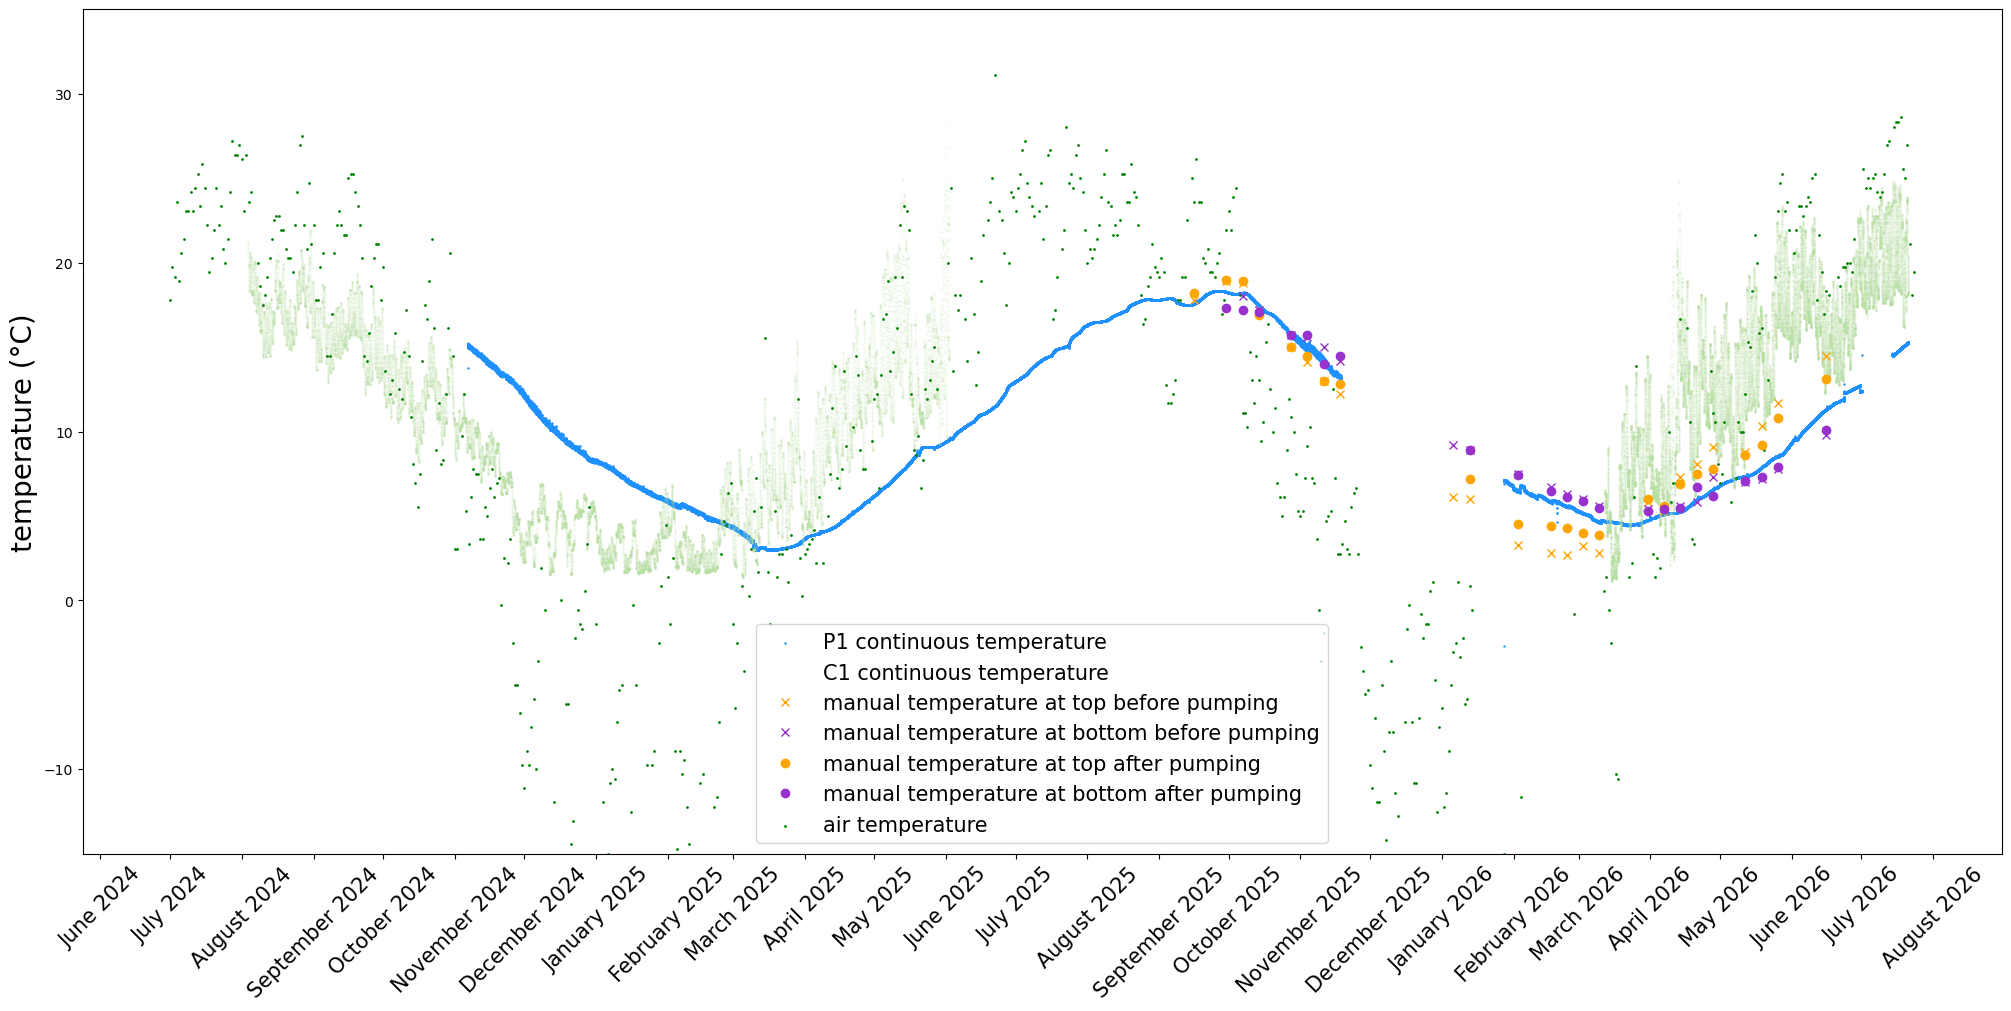

In [33]:

fig, ax = plt.subplots(layout='constrained', figsize=(20,10))

# Plot P1hobodf as a scatter plot with tiny dots
ax.scatter(P1hobodf.index, P1hobodf.FilteredTemp, color="dodgerblue", s = 0.5, label = "P1 continuous temperature")

# Plot the creek temperature as a scatter plot with tiny, transparent dots.
ax.scatter(C1hobodf.index, C1hobodf.FilteredTemp, color = "xkcd:light grey green", alpha = 0.2, s = 0.2, label = "C1 continuous temperature")

# Plot all of the manual data. 
ax.plot(P1mandf.Date, P1mandf.loc[:,"Temp top before"], 'x', color = "orange", label = "manual temperature at top before pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"Temp bottom before"], 'x', color = "darkorchid", label = "manual temperature at bottom before pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"Temp top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"Temp bottom after"], 'o', color = "darkorchid", label = "manual temperature at bottom after pumping")

# Plot the weather data as a scatter plot with slightly larger dots.
ax.scatter(weatherdf.Date, weatherdf.MeanTempC, color = "green", s = 1, label = "air temperature")

# Instead of labelling the x axis with the datetime, corellate the datetime with a string that gives Month and Year.
ax.xaxis.set_major_locator(mdates.MonthLocator())
# '%B %Y' can be adjusted. %d calls the day in digits, etc. 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))

# Rotate the labels.
plt.xticks(rotation=45, fontsize = 15)
# plt.xlabel("time", fontsize = 15)
plt.ylabel("temperature (°C)", fontsize = 20) #Temperature (°C) is a placeholder.

# Ajust the limits to zoom in and out on time periods you'd like to look at in higher resolution.
# plt.xlim((pd.to_datetime("2025-11-18 06"), pd.to_datetime("2025-11-18 16")))
plt.ylim(-15, 35)

# I haven't found a seamless way to code the legend into exactly the spot I want, but here are some of the better ones.
ax.legend(fontsize=15)
# plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize = 20)

plt.show()

Plotting SPC:

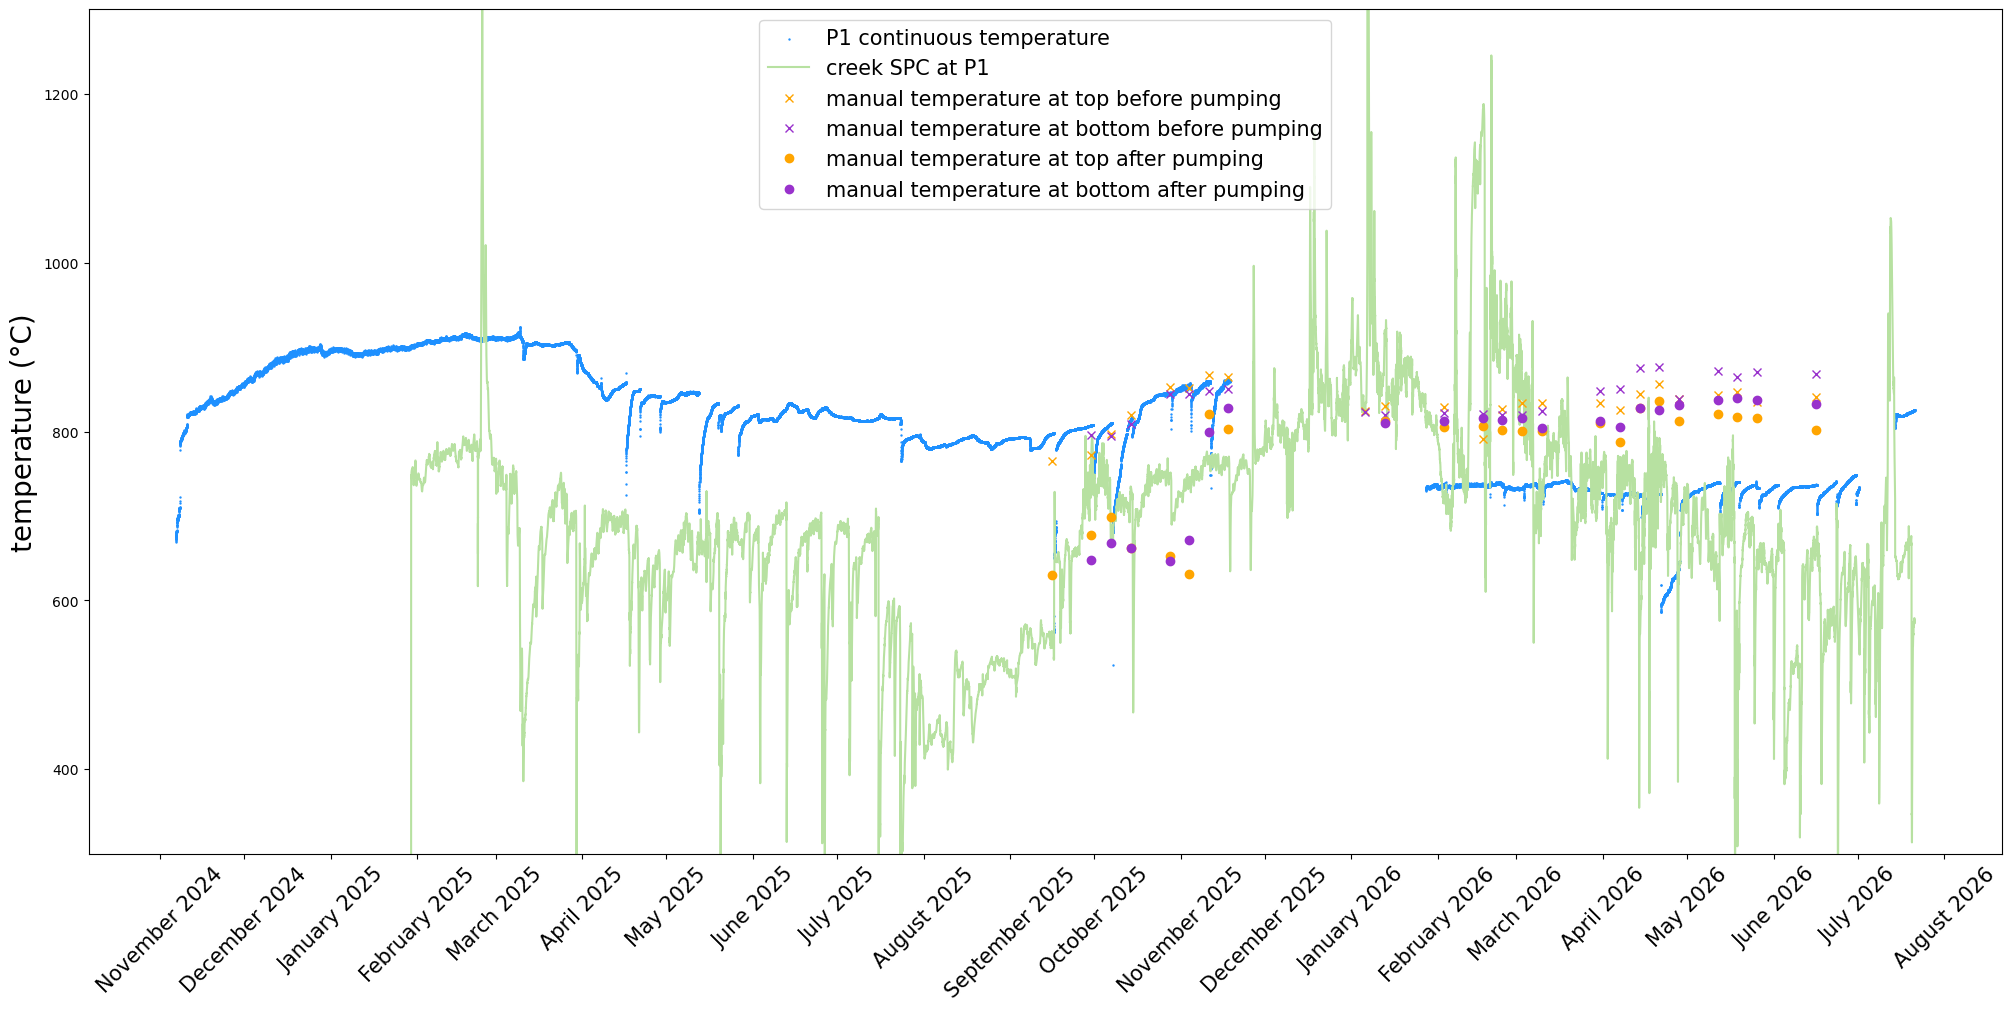

In [59]:

fig, ax = plt.subplots(layout='constrained', figsize=(20,10))

# Plot P1hobodf as a scatter plot with tiny dots.
ax.scatter(P1hobodf.index, P1hobodf.FilteredSPC, color="dodgerblue", s = 0.5, label = "P1 continuous temperature")

# Plot the creek conductivity.
ax.plot(downst.index, downst.FilteredSPC, color = "xkcd:light grey green", label = 'creek SPC at P1')

# Plot all of the manual data. 
ax.plot(P1mandf.Date, P1mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual temperature at top before pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"SPC bottom before"], 'x', color = "darkorchid", label = "manual temperature at bottom before pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"SPC bottom after"], 'o', color = "darkorchid", label = "manual temperature at bottom after pumping")


# Instead of labelling the x axis with the datetime, corellate the datetime with a string that gives Month and Year.
ax.xaxis.set_major_locator(mdates.MonthLocator())
# '%B %Y' can be adjusted. %d calls the day in digits, etc. 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))

# Rotate the labels.
plt.xticks(rotation=45, fontsize = 15)
# plt.xlabel("time", fontsize = 15)
plt.ylabel("temperature (°C)", fontsize = 20) #Temperature (°C) is a placeholder.

# Ajust the limits to zoom in and out on time periods you'd like to look at in higher resolution.
# plt.xlim((pd.to_datetime("2025-11-18 06"), pd.to_datetime("2025-11-18 16")))
plt.ylim(300, 1300)

# I haven't found a seamless way to code the legend into exactly the spot I want, but here are some of the better ones.
ax.legend(fontsize=15)
# plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize = 20)

plt.show()

# Other cool plots

Plotting SPC against rainfall:

In [60]:
# Add precipitation data:
precip = pd.read_csv("NOAAFaribaultPrecipitation.csv")
precip["Date"] = pd.to_datetime(precip["Date"])
precip = precip[precip["PrecipitationCM"] != 0]

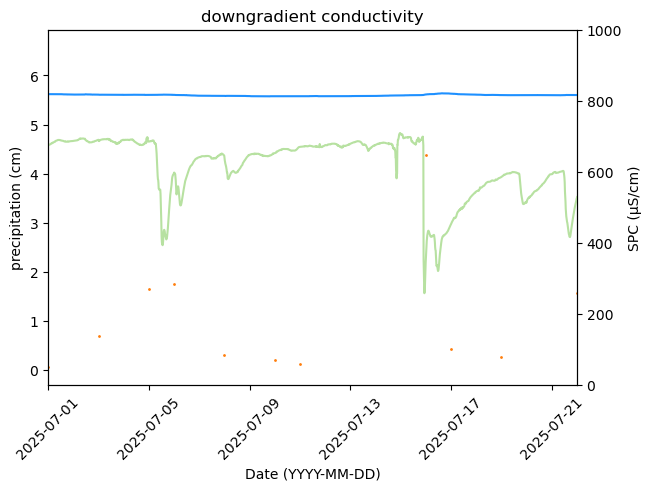

In [62]:
fig, ax1 = plt.subplots(layout='constrained')
ax1.set_xlabel('Date (YYYY-MM-DD)')
ax1.set_ylabel('precipitation (cm)')
rain = ax1.scatter(precip.Date, precip.PrecipitationCM, alpha = 1, s= 1, color = 'tab:orange', label = "precipitation (cm)")
# ax.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], color = "green", s = 1, label = "air temperature")

ax1.tick_params(axis='x', rotation=45)
# ax1.set_ylim(0, 3)


ax2 = ax1.twinx() 
ax2.set_ylabel('SPC (µS/cm)') 
P5 = ax2.plot(P1hobodf.index, P1hobodf.FilteredSPC, color="dodgerblue", label = "P5 continuous SPC")
C5 = ax2.plot(downst.index, downst.FilteredSPC,  color = "xkcd:light grey green", label = 'creek SPC at P5')
ax2.set_ylim(0, 1000)
ax2.set_xlim((pd.to_datetime("2025-07-01"), pd.to_datetime("2025-07-22")))

plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
plt.title("downgradient conductivity")
# leg = rain + C5 + C1
# labs = [l.get_label() for l in leg]
# ax1.legend(leg, labs)

# plt.xlim(pd.to_datetime("2025-04"), pd.to_datetime("2025-05"))

plt.show();